In [1]:
import numpy as np
#import ray
import matplotlib.pyplot as plt
import pythtb
import wannierberri as wberri
from wannierberri.system import System_PythTB
from hall_ps.hall_positional_shift import Data_K_pos_shift
_=wberri.welcome()


.::    .   .::: .:::::::.  :::.    :::.:::.    :::. :::.,::::::  :::::::..       :::::::.  .,::::::  :::::::..   :::::::..   :::
';;,  ;;  ;;;' '  ;;`;;  ` `;;;;,  `;;;`;;;;,  `;;; ;;;;;;;''''  ;;;;``;;;;       ;;;'';;' ;;;;''''  ;;;;``;;;;  ;;;;``;;;;  ;;;
 '[[, [[, [['    ,[[ '[[,    [[[[[. '[[  [[[[[. '[[ [[[ [[cccc    [[[,/[[['       [[[__[[\. [[cccc    [[[,/[[['   [[[,/[[['  [[[
   Y$c$$$c$P    c$$$cc$$$c   $$$ "Y$c$$  $$$ "Y$c$$ $$$ $$""""    $$$$$$c         $$""""Y$$ $$""""    $$$$$$c     $$$$$$c    $$$
    "88"888      888   888,  888    Y88  888    Y88 888 888oo,__  888b "88bo,    _88o,,od8P 888oo,__  888b "88bo, 888b "88bo,888
     "M "M"      YMM   ""`   MMM     YM  MMM     YM MMM """"YUMMM MMMM   "W"     ""YUMMMP"  """"YUMMM MMMM   "W"  MMMM   "W" MMM

Version: 26.4.6.dev10+g99ce3f530.d20260415


   HTTP://WANNIER-BERRI.ORG  

Checking dependencies …
irrep : 2.6.3
spglib : 2.7.0
numpy : 2.4.2
scipy : 1.15.2
spgrep : 0.5.0
numba : 0.64.0
pyfftw : 0.15.1
seekpath : 2.2.1
mat

# WannierBerri PythTB

In [2]:
from ferroaxial_model import model_ferroaxial_pythtb, visualise

# k-resolved

In [19]:
from wannierberri.formula.covariant import QuantumMetric_ab
from wannierberri.formula.covariant import DerQuantumMetric_ab_d
from hall_ps.hall_positional_shift import HallPositionalShift, PositionalShiftFormula

Efermi = np.linspace(-10, +10, 1601)

def plot_k_resolved( parameters_model, k_nodes, k_labels):
    model = model_ferroaxial_pythtb(**parameters_model)
    title = ", ".join([f"{k}={v}" for k, v in sorted(parameters_model.items())])
    filename="_".join([f"{k}={v}" for k, v in sorted(parameters_model.items())])
    visualise(model, title=title, filename=filename)
    system = System_PythTB(model)

    for node, label in zip(k_nodes, k_labels):
        print(f"{label}: {node} (reduced), {np.dot(node, system.recip_lattice)} (cartesian)") 
    

    nband = 4 if parameters_model.get("spin", False) else 2

    path = wberri.Path.from_nodes(system,
        nodes=k_nodes,
        labels=k_labels,
        nk=200
    )
    fig, ax = plt.subplots(figsize=(6, 4))
    kpoints_cartesian = path.get_kpoints_cart()
    kmax = np.max(np.abs(kpoints_cartesian)) * 1.1
    ax.plot(kpoints_cartesian[:, 0], kpoints_cartesian[:, 1], marker='o')
    for node, label in zip(k_nodes, k_labels):
        k_cart = np.dot(node, system.recip_lattice)
        ax.text(k_cart[0], k_cart[1], label, fontsize=12, ha='right', va='bottom')
    ax.set_xlim(-kmax, kmax)
    ax.set_ylim(-kmax, kmax)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel("kx (1/Angstrom)")
    ax.set_ylabel("ky (1/Angstrom)")
    ax.set_title("k-path in Cartesian Coordinates")
    ax.grid(True)
    fig.tight_layout()
    fig.savefig(f"k_path_cartesian.pdf")  

    tabulator =wberri.calculators.TabulatorAll(
        {
            "energy": wberri.calculators.tabulate.Energy(),
            "g": wberri.calculators.tabulate.Tabulator(Formula=QuantumMetric_ab),
            "dg_dk": wberri.calculators.tabulate.Tabulator(Formula=DerQuantumMetric_ab_d),
            "pos_shift_morb": wberri.calculators.tabulate.Tabulator(Formula=PositionalShiftFormula, 
                                                                    kwargs_formula={"morb_part": True, 
                                                                                "metric_part":False},
                                                                                ),
            "pos_shift_metric": wberri.calculators.tabulate.Tabulator(Formula=PositionalShiftFormula, 
                                                                    kwargs_formula={"morb_part": False,
                                                                                "metric_part":True},),
            "pos_shift_total": wberri.calculators.tabulate.Tabulator(Formula=PositionalShiftFormula, 
                                                                    kwargs_formula={"morb_part": True,
                                                                                "metric_part":True,
                                                                                "spin_part":False},),
                                                                                
            "Omega" : wberri.calculators.tabulate.BerryCurvature(),
            'pos_shift_calc' : HallPositionalShift(Efermi=Efermi, k_resolved=True, kwargs_formula={"morb_part": True, "external_terms": False})

        },
        mode="path"
    )
    
    result = wberri.run(
        system=system,
        grid=path,
        calculators={"tab": tabulator},
        data_k_class=Data_K_pos_shift
    )
    res_tab = result.results["tab"]
    energy = res_tab.get_data("energy")   
    print ("Energy shape:", energy.shape)
    g = res_tab.get_data("g")         
    print ("g shape:", g.shape)
    dg_dk = res_tab.get_data("dg_dk") 
    print ("dg_dk shape:", dg_dk.shape)
    pos_shift_morb = res_tab.get_data("pos_shift_morb")  
    print ("pos_shift_morb shape:", pos_shift_morb.shape)
    pos_shift_metric = res_tab.get_data("pos_shift_metric") 
    print ("pos_shift_metric shape:", pos_shift_metric.shape)
    Omega = res_tab.get_data("Omega")        
    print ("Omega shape:", Omega.shape)
    pos_shift_total = res_tab.get_data("pos_shift_total") 
    print ("pos_shift_total shape:", pos_shift_total.shape)
    # pos_shift_calc = res_tab.results["pos_shift_calc"].data
    # print ("pos_shift_calc shape:", pos_shift_calc.shape)

    kline = path.getKline()
    x_ticks_labels = []
    x_ticks_positions = []
    for k, v in path.labels.items():
        x_ticks_labels.append(v)
        x_ticks_positions.append(kline[k])

    linestyles = ['-', '--', '-.', ':']
    colors = ['b', 'g', 'r', 'c', 'm', 'y']
    def make_subplot(axes, data_dict, ylabel, title):
        for k,v in data_dict.items():
            for ib in range(nband):
                axes.plot(kline, v[:,ib], label=f"band {ib}, {k}", linestyle=linestyles[ib % len(linestyles)], color=colors[ib % len(colors)])
        axes.set_ylabel(ylabel)
        axes.set_title(title)
        axes.set_xticks(ticks=x_ticks_positions)
        axes.set_xticklabels(labels=x_ticks_labels)
        axes.grid(True, which='both', linestyle='--', linewidth=0.5)
        axes.legend()

    fig, axes = plt.subplots(3, 4, figsize=(18, 30))
    make_subplot(axes[0,0], {"": energy}, "Energy (eV)", "Band Structure")
    for l, ij in enumerate([(0,2), (1,2), (0,0), (1,1)]):
        i,j = ij
        a = "xyz"[i]
        b = "xyz"[j]
        label = a+b
        make_subplot(axes[1, l], {r"$F_{"+label+r"}^O$": pos_shift_morb[:, :, i, j] }, 
                            r"$\AA^3$" , f"Positional Shift (Morb Part) ({label})")
        make_subplot(axes[2, l], {r"$F_{"+label+r"}^G$": pos_shift_metric[:, :, i, j],}, 
                            r"$\AA^3$" , f"Positional Shift (Metric Part) ({label})")
        # make_subplot(axes[3, l], {r"F_{"+label+r"}^{tot}$" : pos_shift_total[:, :, i, j],}, 
        #                     r"$\AA^3$" , f"Positional Shift (Total) ({label})")
    # parameters in the figure title
    fig.suptitle("Ferroaxial TB Model: " + title, fontsize=20)
    fig.savefig(f"ferroaxial_tb_{filename}.pdf")
    plt.tight_layout()
    fig.show()




        


Reading the system from PythTB model. Needed data: {'Ham'}
number of wannier functions: 4
hopping : (2, 2) (25, 4, 4) 12 (2, 2)
hopping : (2, 2) (25, 4, 4) 13 (2, 2)
hopping : (2, 2) (25, 4, 4) 11 (2, 2)
hopping : (2, 2) (25, 4, 4) 9 (2, 2)
hopping : (2, 2) (25, 4, 4) 10 (2, 2)
hopping : (2, 2) (25, 4, 4) 8 (2, 2)
hopping : (2, 2) (25, 4, 4) 3 (2, 2)
hopping : (2, 2) (25, 4, 4) 4 (2, 2)
hopping : (2, 2) (25, 4, 4) 2 (2, 2)
hopping : (2, 2) (25, 4, 4) 24 (2, 2)
hopping : (2, 2) (25, 4, 4) 9 (2, 2)
hopping : (2, 2) (25, 4, 4) 6 (2, 2)
hopping : (2, 2) (25, 4, 4) 21 (2, 2)
hopping : (2, 2) (25, 4, 4) 1 (2, 2)
hopping : (2, 2) (25, 4, 4) 7 (2, 2)
hopping : (2, 2) (25, 4, 4) 15 (2, 2)
hopping : (2, 2) (25, 4, 4) 15 (2, 2)
hopping : (2, 2) (25, 4, 4) 19 (2, 2)
hopping : (2, 2) (25, 4, 4) 19 (2, 2)
hopping : (2, 2) (25, 4, 4) 3 (2, 2)
hopping : (2, 2) (25, 4, 4) 3 (2, 2)
shape of Ham_R = (25, 4, 4)
Real-space lattice:
 [[ 1.50000000e+00 -8.66025404e-01  0.00000000e+00]
 [-1.94289029e-16  1.73

/home/stepan/github/wannier-berri/.conda/lib/python3.12/site-packages/wannierberri/parallel.py:121: UserWarning: ray package found, but ray is not initialized, running in serial mode
  warnings.warn("ray package found, but ray is not initialized, running in serial mode")
/home/stepan/github/wannier-berri/.conda/lib/python3.12/site-packages/wannierberri/grid/path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


time for processing    996 K-points on   1 processes:     4.9344 ; per K-point          0.0050 ; proc-sec per K-point          0.0050
time1 =  2.384185791015625e-07
Totally processed 996 K-points 
run() finished
Energy shape: (996, 4)
g shape: (996, 4, 3, 3)
dg_dk shape: (996, 4, 3, 3, 3)
pos_shift_morb shape: (996, 4, 3, 3)
pos_shift_metric shape: (996, 4, 3, 3)
Omega shape: (996, 4, 3)
pos_shift_total shape: (996, 4, 3, 3)


/tmp/ipykernel_258465/4051074208.py:127: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Reading the system from PythTB model. Needed data: {'Ham'}
number of wannier functions: 4
hopping : (2, 2) (25, 4, 4) 12 (2, 2)
hopping : (2, 2) (25, 4, 4) 13 (2, 2)
hopping : (2, 2) (25, 4, 4) 11 (2, 2)
hopping : (2, 2) (25, 4, 4) 9 (2, 2)
hopping : (2, 2) (25, 4, 4) 10 (2, 2)
hopping : (2, 2) (25, 4, 4) 8 (2, 2)
hopping : (2, 2) (25, 4, 4) 3 (2, 2)
hopping : (2, 2) (25, 4, 4) 4 (2, 2)
hopping : (2, 2) (25, 4, 4) 2 (2, 2)
hopping : (2, 2) (25, 4, 4) 24 (2, 2)
hopping : (2, 2) (25, 4, 4) 9 (2, 2)
hopping : (2, 2) (25, 4, 4) 6 (2, 2)
hopping : (2, 2) (25, 4, 4) 21 (2, 2)
hopping : (2, 2) (25, 4, 4) 1 (2, 2)
hopping : (2, 2) (25, 4, 4) 7 (2, 2)
hopping : (2, 2) (25, 4, 4) 15 (2, 2)
hopping : (2, 2) (25, 4, 4) 15 (2, 2)
hopping : (2, 2) (25, 4, 4) 19 (2, 2)
hopping : (2, 2) (25, 4, 4) 19 (2, 2)
hopping : (2, 2) (25, 4, 4) 3 (2, 2)
hopping : (2, 2) (25, 4, 4) 3 (2, 2)
shape of Ham_R = (25, 4, 4)
Real-space lattice:
 [[ 1.50000000e+00 -8.66025404e-01  0.00000000e+00]
 [-1.94289029e-16  1.73

/home/stepan/github/wannier-berri/.conda/lib/python3.12/site-packages/wannierberri/parallel.py:121: UserWarning: ray package found, but ray is not initialized, running in serial mode
  warnings.warn("ray package found, but ray is not initialized, running in serial mode")
/home/stepan/github/wannier-berri/.conda/lib/python3.12/site-packages/wannierberri/grid/path.py:272: UserWarning: symmetry is not used for a tabulation along path
  warnings.warn("symmetry is not used for a tabulation along path")


time for processing    996 K-points on   1 processes:     4.7461 ; per K-point          0.0048 ; proc-sec per K-point          0.0048
time1 =  4.76837158203125e-07
Totally processed 996 K-points 
run() finished
Energy shape: (996, 4)
g shape: (996, 4, 3, 3)
dg_dk shape: (996, 4, 3, 3, 3)
pos_shift_morb shape: (996, 4, 3, 3)
pos_shift_metric shape: (996, 4, 3, 3)
Omega shape: (996, 4, 3)
pos_shift_total shape: (996, 4, 3, 3)


/tmp/ipykernel_258465/4051074208.py:127: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


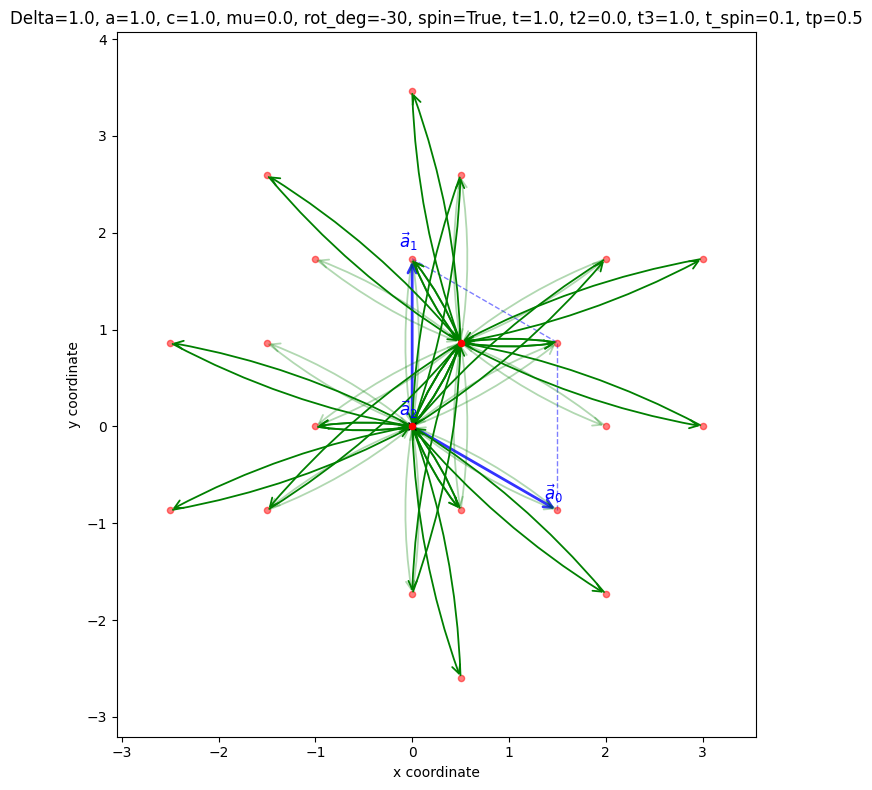

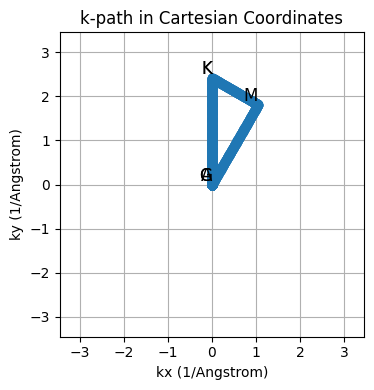

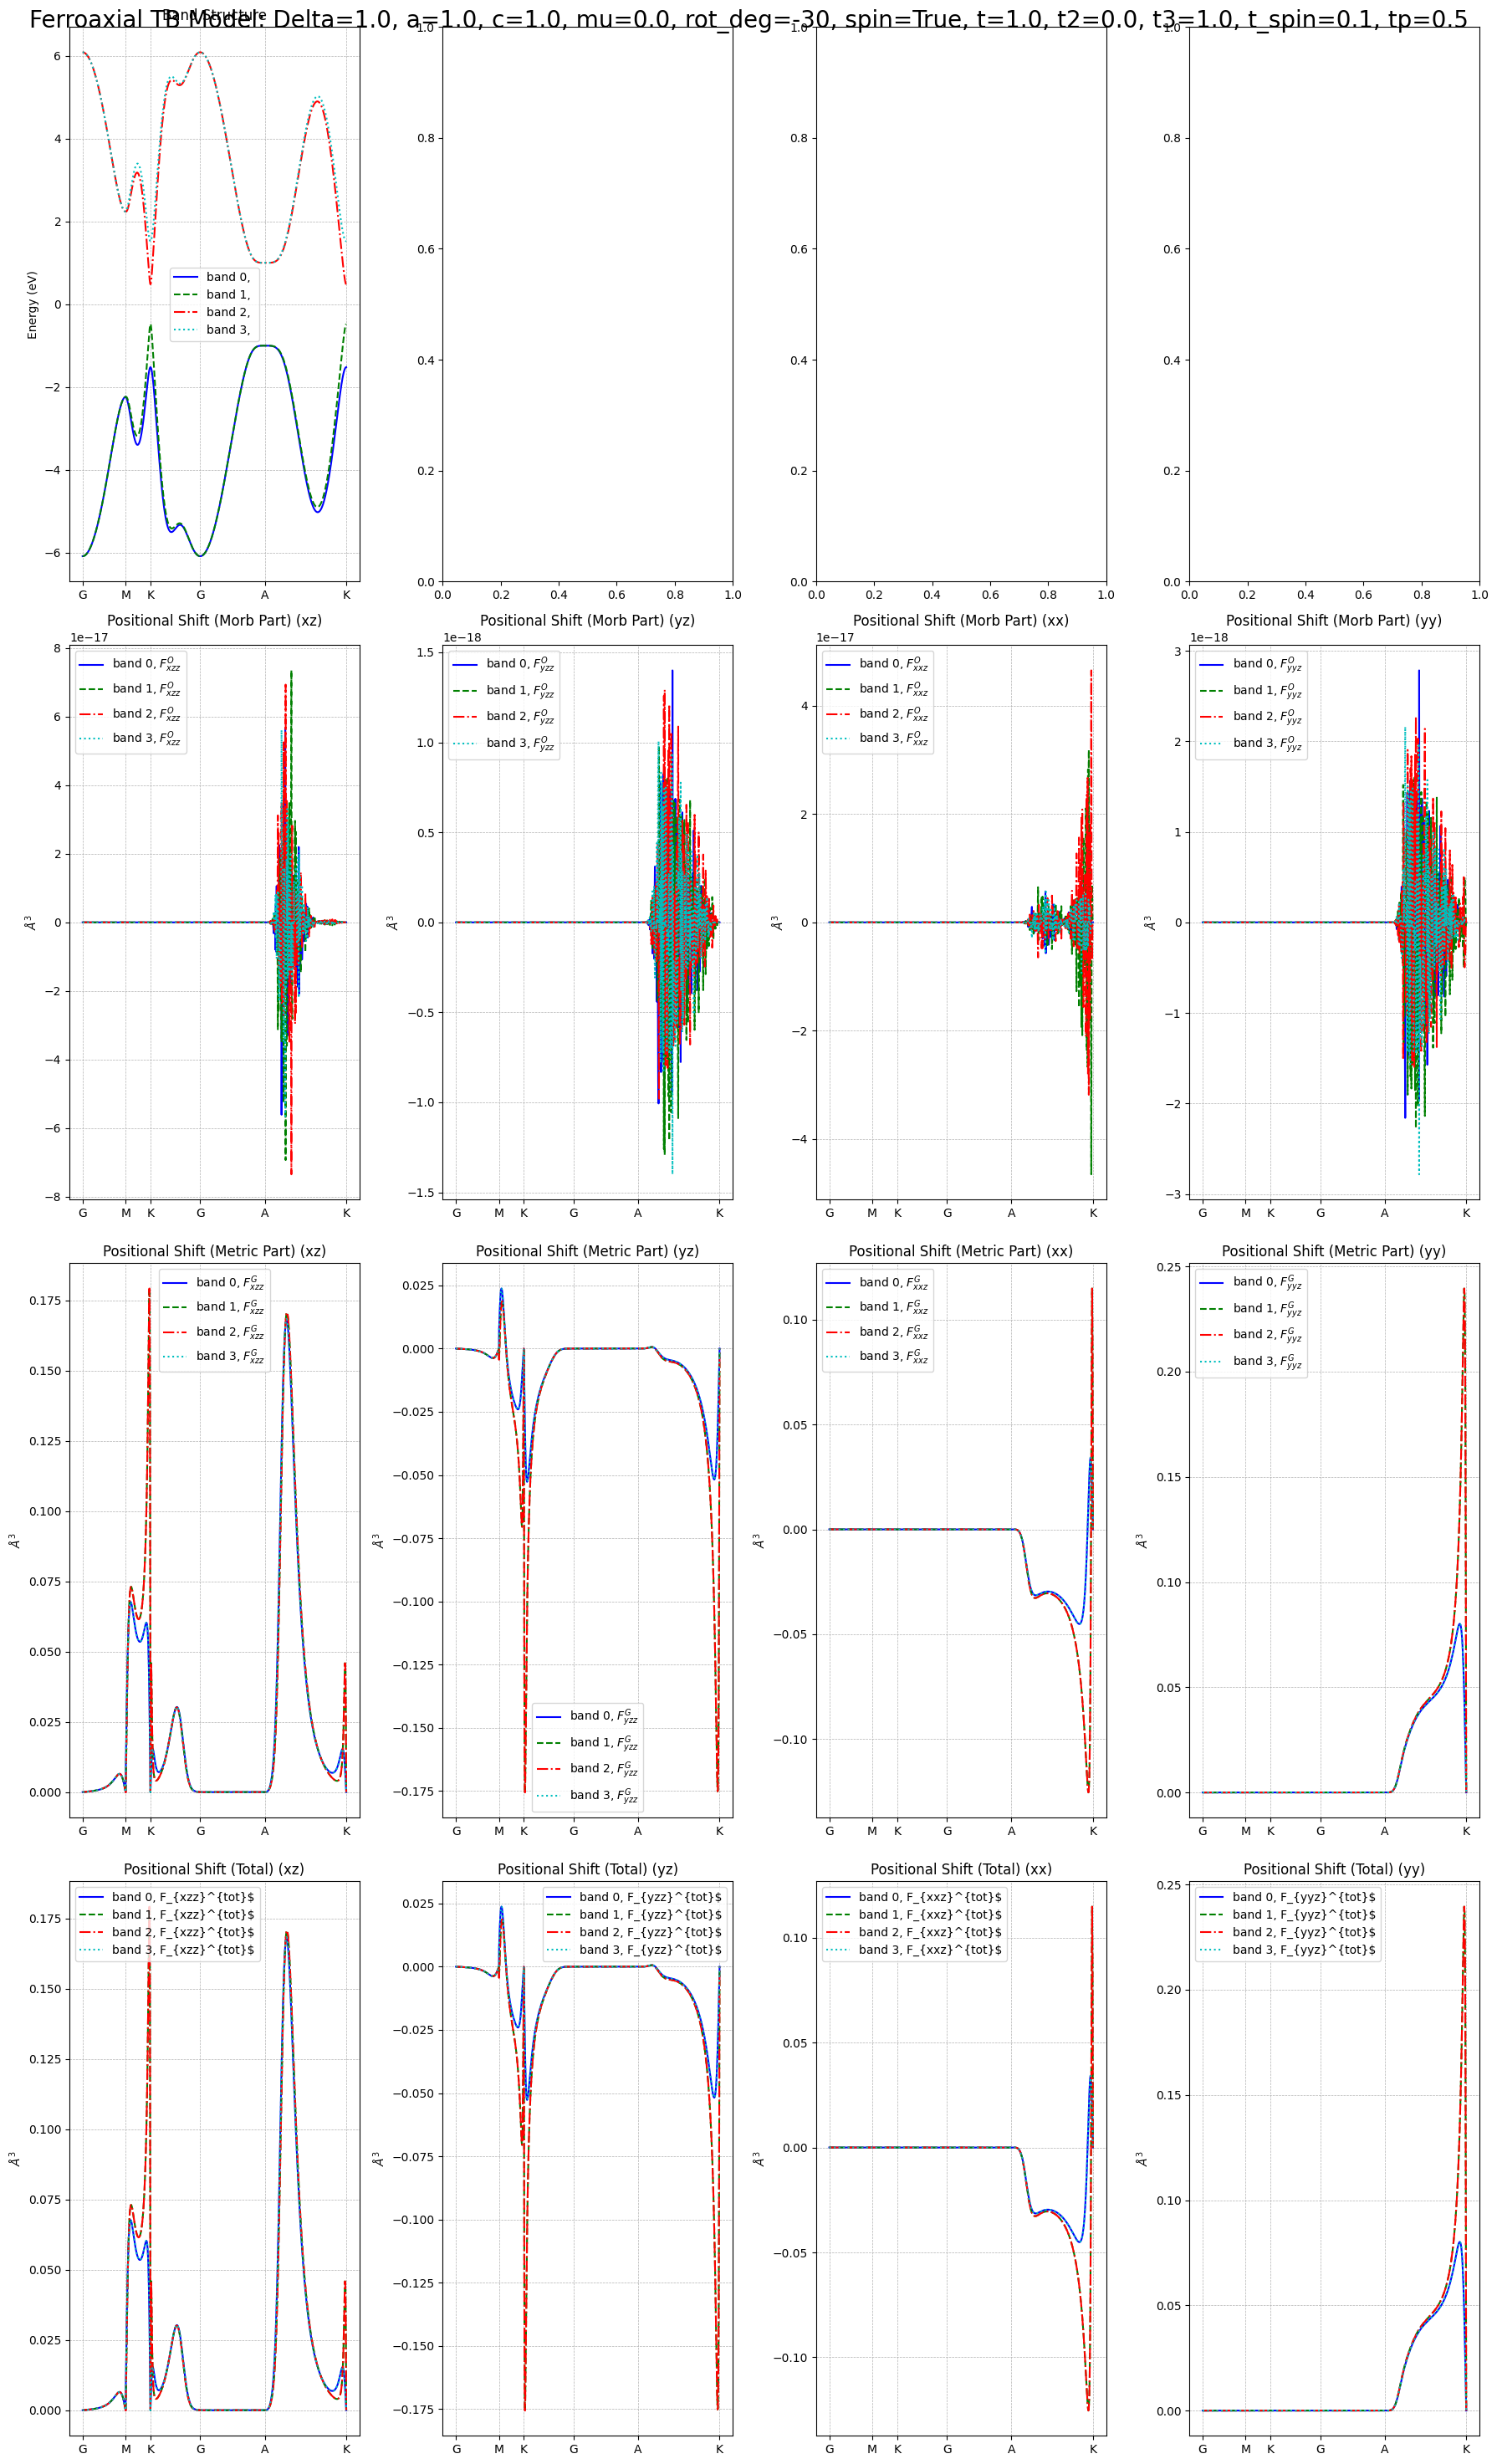

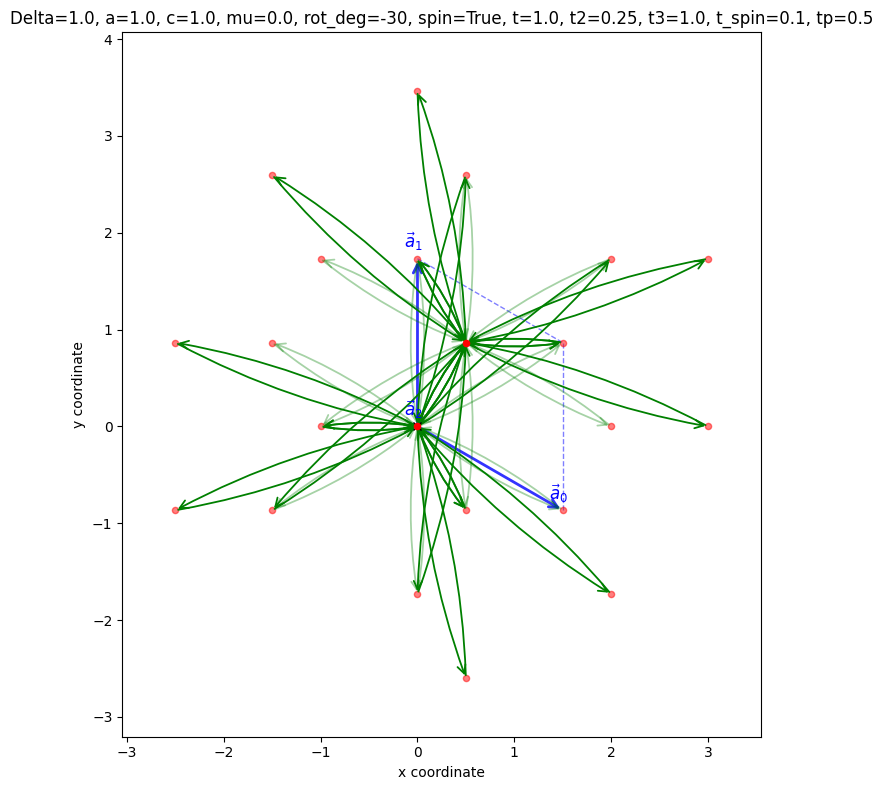

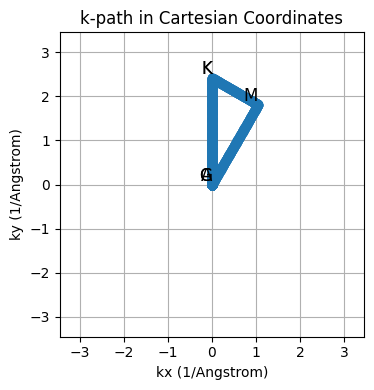

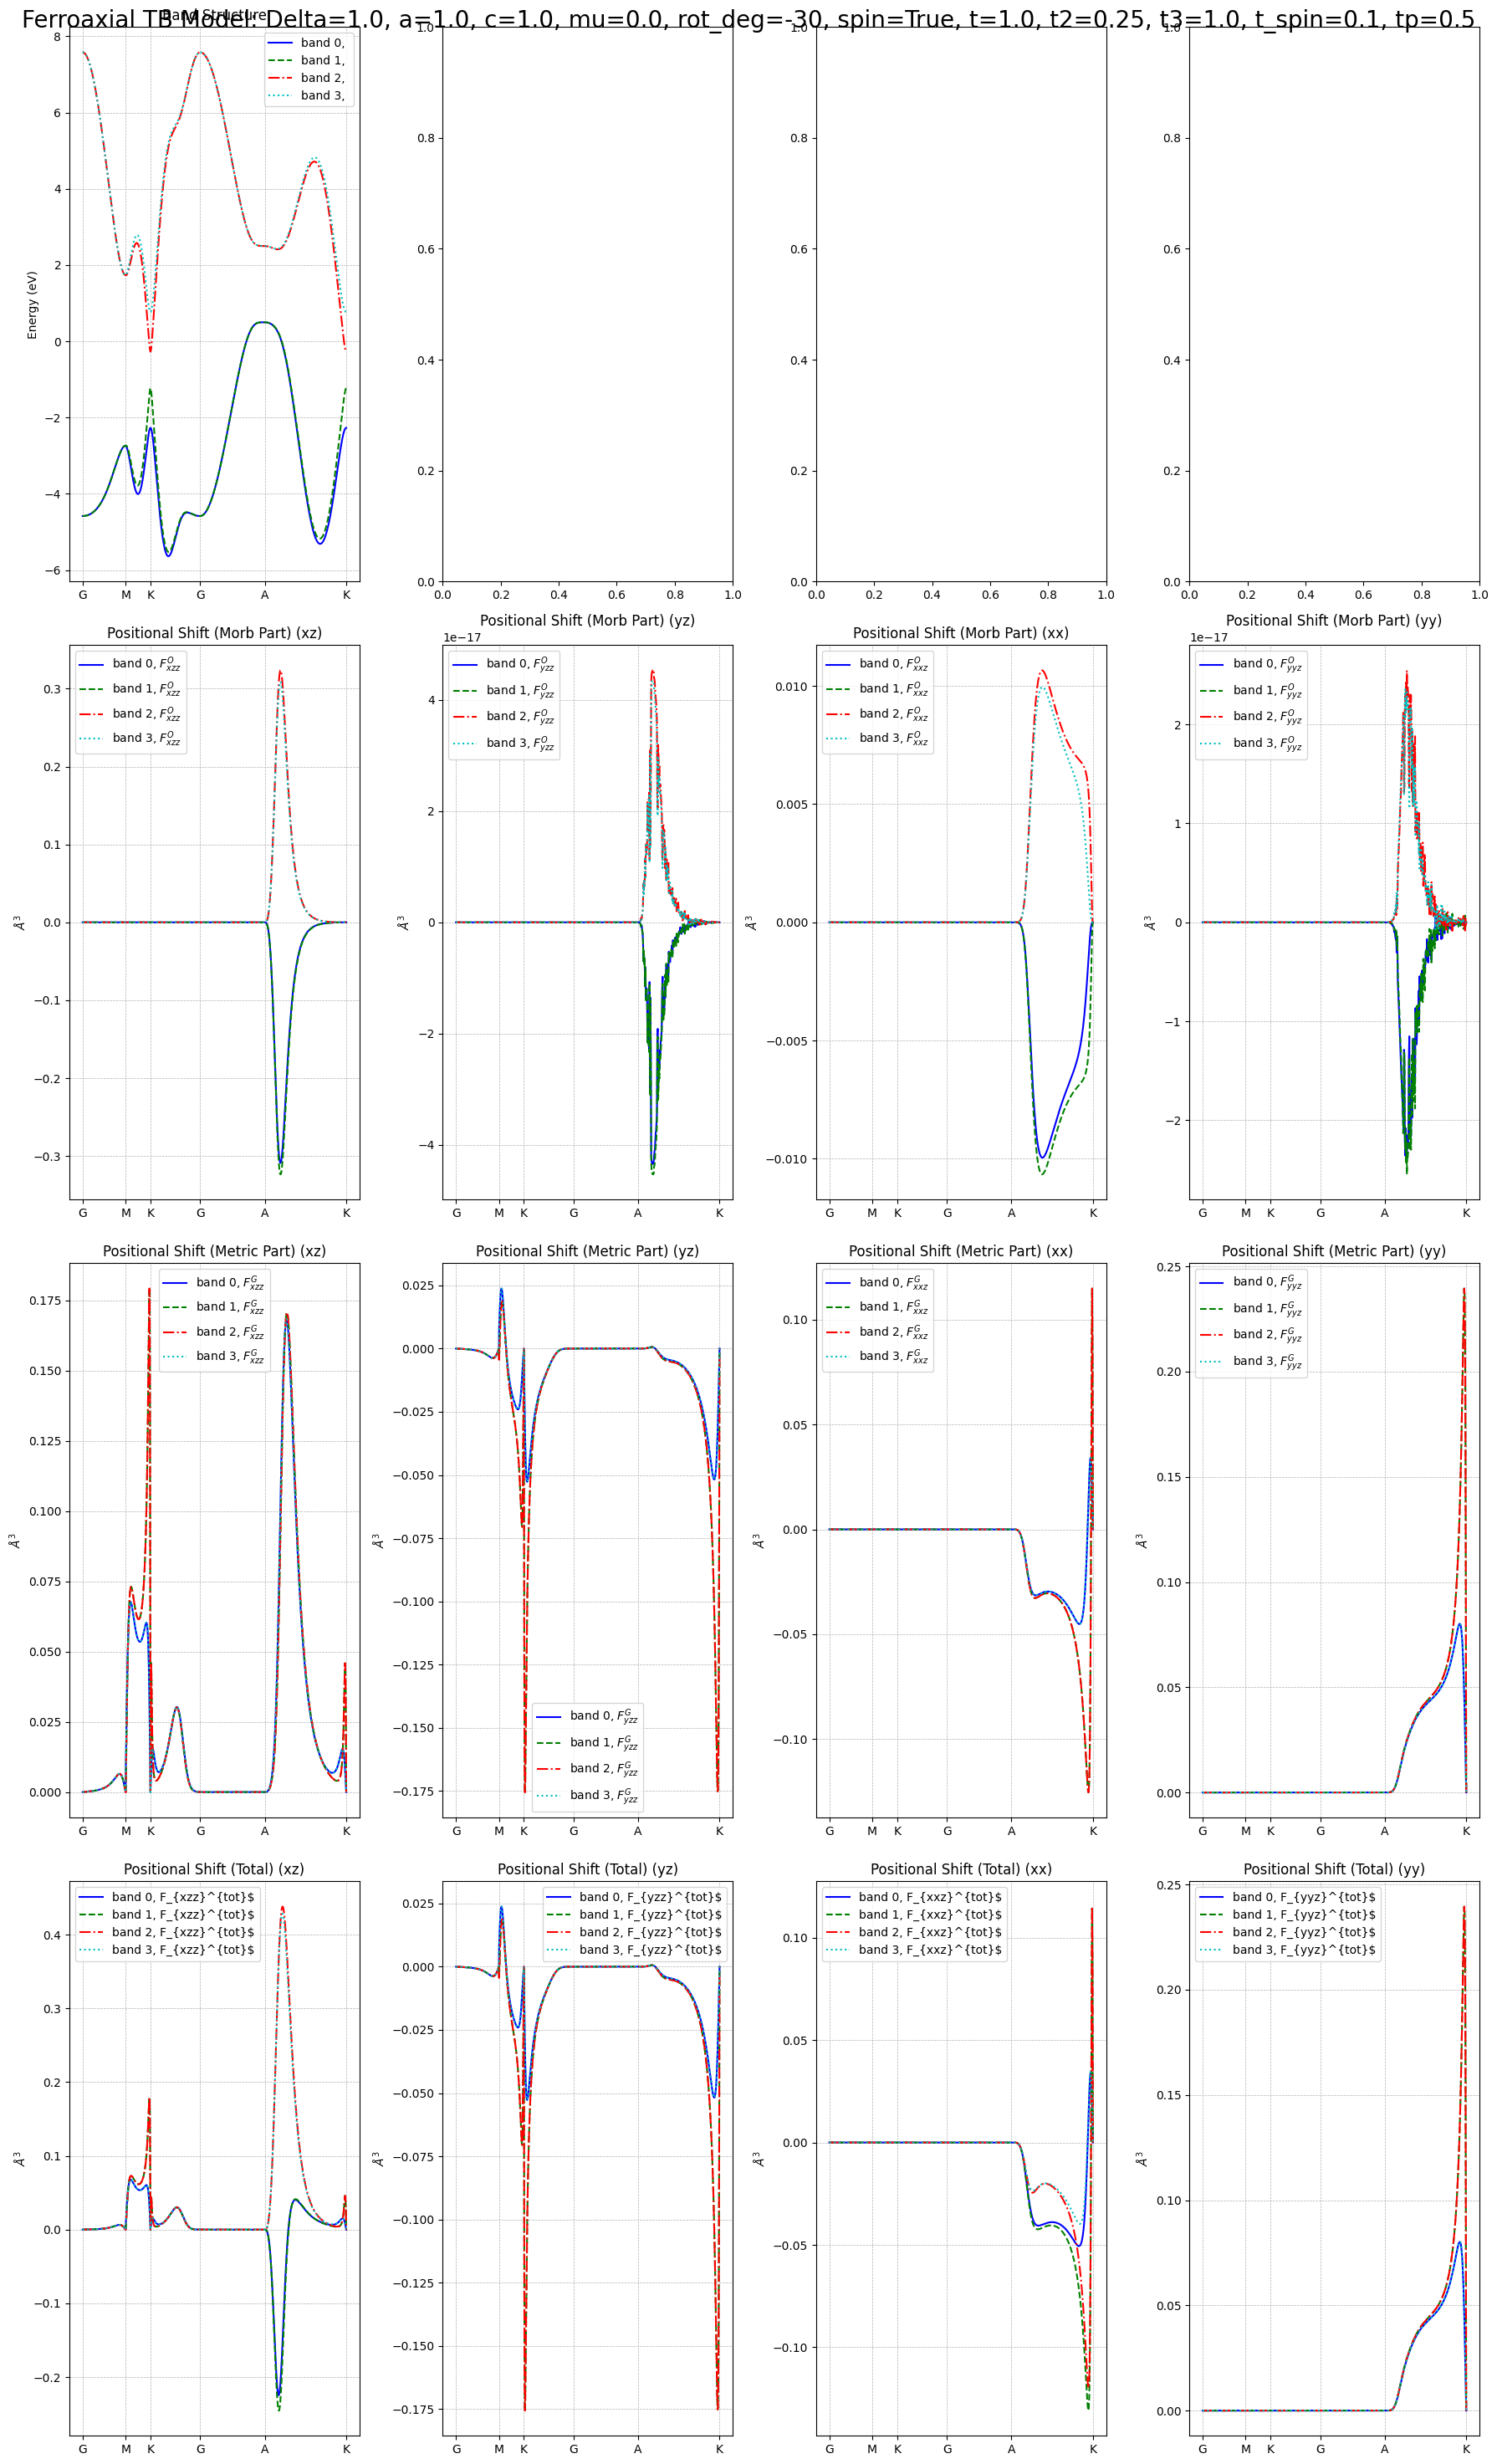

In [ ]:
nodes=[
        [0.0, 0.0, 0.0],  # G (Gamma): Center of the BZ
        [0.0, 0.5, 0.0],  # M: Center of the rectangular side face
        [-1/3, 2/3, 0.0],   # K: Corner of the hexagonal face
        [0.0, 0.0, 0.0],  # G (Gamma): Center of the BZ
        [0.0, 0.0, 0.5],  # A: Center of the top face (k_z = pi/c)
        [-1/3, 2/3, 0.0]   # K: Corner of the hexagonal face
    ]
labels=["G", "M", "K", "G", "A", "K"]

# parameters1 = dict(mu=0.0, t=1.0, tp=0.5, Delta=1.0, t3=1.0, t2=0.0, a=1.0, c=1.0, rot_deg=-30,
#                     spin=True, t_spin=0.1)
# plot_k_resolved(parameters1, k_nodes=nodes, k_labels=labels)
parameters2 = dict(mu=0.0, t=1.0, tp=0.5, Delta=1.0, t3=1.0, t2=0.25, a=1.0, c=1.0, rot_deg=-30,
                    spin=True, t_spin=-0.1)
plot_k_resolved(parameters2, k_nodes=nodes, k_labels=labels)

In [6]:
from wannierberri.symmetry.point_symmetry import PointGroup
pg = PointGroup(["C3z", "TimeReversal"])
pg.get_symmetric_components(rank=2, Iodd=False, TRodd=False)

['0=xz=yz=zx=zy', 'xx=yy', 'xy=-yx', 'zz']